**Implementazione con k-d tree**
Necessario installare la libreria scipy che implementa una versione ottimizzata dei k-d tree.

In [16]:
from scipy.spatial import KDTree
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

Esempio utilizzo:

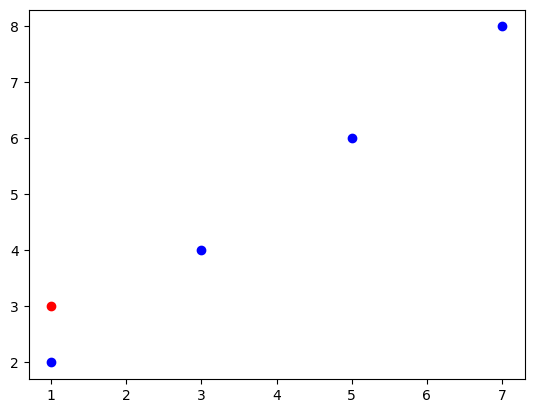

In [17]:
points = [(1,2), (3,4), (5,6), (7,8)]
p = (1,3)

plt.scatter([x for x,y in points], [y for x,y in points], color='blue')
plt.scatter([p[0]], [p[1]], color='red')

In [18]:
tree = KDTree(points)
dist, idx = tree.query(p)  # punto di query
print(points[idx], dist)

(1, 2) 1.0


## KDTree

Un KDTree è una struttura dati usata per accelerare la ricerca dei vicini più prossimi.

Nel k-NN standard, per classificare un punto bisogna confrontarlo con tutti i punti del training set.

Se il training set contiene `n` esempi, la ricerca dei vicini richiede molti confronti.

Il KDTree organizza i punti in una struttura ad albero.

In questo modo, durante la ricerca, alcune regioni dello spazio possono essere escluse senza confrontare il punto di query con tutti gli esempi.

La riga:

```python
tree = KDTree(points)
```

costruisce l'albero.

La riga:

```python
dist, idx = tree.query(p)
```

cerca il punto più vicino a `p`.

Restituisce:

```text
dist = distanza dal vicino più prossimo
idx  = indice del vicino più prossimo
```

In [19]:
tree.query(p, k=2)

(array([1.        , 2.23606798]), array([0, 1]))

## Ricerca dei k vicini

La funzione:

```python
tree.query(p, k=2)
```

restituisce i 2 punti più vicini a `p`.

Se `k=1`, restituisce un solo vicino.

Se `k=5`, restituisce i 5 vicini più prossimi.

Nel k-NN, questi indici vengono usati per recuperare le etichette dei vicini e calcolare la classe più frequente.

Ridefinizione della classe KNN

In [20]:
def train_test_split(X, y, train_size = 0.7):
    etichette = np.unique(y)
    n = X.shape[0]
    train_idxs = []
    for lab in etichette:
        n0 = np.where(y==lab)[0].shape[0] #numero di campioni con etichetta lab
        train_idxs.append(np.random.choice(np.where(y==lab)[0], size = int(n0*train_size), replace = False))
    train_idxs = np.concatenate(train_idxs)
    test_idxs = np.setdiff1d(np.arange(n), train_idxs)
    return X[train_idxs], y[train_idxs], X[test_idxs], y[test_idxs]
def mode( a ):
    '''
    parametro: a, un array-like

    return: l'elemento più frequente ed il numero di occorrenze
    '''

    itms, cnts = np.unique(np.array(a), return_counts=True )

    return itms[np.argmax(cnts)], max(cnts)

class KNN(object):
    def __init__(self, k = 5):
        self.k = k
        self.X = None
        self.y = None
        self.tree = None
    
    def fit(self, X, y):
        self.X = X
        self.y = y
        self.tree = KDTree(self.X)
        
    def predict(self, x):        
        # Ottiene gli indici dei k punti più vicini
        _, k_indices = self.tree.query(x, k=self.k)
        
        # Prende le etichette corrispondenti
        return mode(self.y[k_indices])

## KNN con KDTree

Questa versione del k-NN usa un KDTree per rendere più efficiente la ricerca dei vicini.

Nel metodo `fit` non vengono calcolati pesi o parametri del modello.

Vengono salvati:

```python
self.X = X
self.y = y
```

e viene costruito il KDTree:

```python
self.tree = KDTree(self.X)
```

Nel metodo `predict`, invece di calcolare manualmente tutte le distanze, viene usato:

```python
_, k_indices = self.tree.query(x, k=self.k)
```

Questa riga restituisce gli indici dei `k` punti più vicini.

Poi vengono prese le etichette corrispondenti:

```python
self.y[k_indices]
```

e viene restituita la moda, cioè la classe più frequente tra i vicini.

In [36]:
s = os.path.join('materiale_2026/dataset/', '01-02-iris.csv')
df = pd.read_csv(s, header=None, encoding='utf-8')
X = df.iloc[:, [0,1]].values
y = df.iloc[:, 4].values
df

,0,1,2,3,4
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [37]:
X = df.iloc[:, :-1].values 
y = df.iloc[:, 4].values
X_train, y_train, X_test, y_test = train_test_split(X, y)

**Valutazione**

In [22]:
knn = KNN()
knn.fit(X_train, y_train)

preds = np.array([knn.predict(x)[0] for x in X_test]) == y_test
print('Accuratezza ', preds.sum()/preds.shape[0])

Accuratezza  0.9777777777777777


**Esercizio**
Sviluppare un classificatore binario basato sul modello k-Nearest in grado di distinguere tra quadrati ed altre forme geometriche a partire da una sequenza di punti che ne rappresenta il contorno.
Il dataset è composto da 200 campioni etichettati con 0 (non quadrato) e 1 (quadrato). Ogni forma è rappresentata da una sequenza x_0, y_0, x_1, y_1, ... dove (x_0, y_0) è il primo numero della sequenza.
I punti e la sua classificazione sono separati da ;, mentre le coordinate sono separate da ,.

## Dataset dei quadrati

Ogni riga del dataset rappresenta una forma geometrica.

La prima colonna contiene una sequenza di coordinate:

```text
x0, y0, x1, y1, x2, y2, ...
```

La seconda colonna contiene l'etichetta:

```text
1 = quadrato
0 = non quadrato
```

Il problema è trasformare ogni forma in un vettore di feature numeriche.

Il k-NN non può confrontare direttamente stringhe di coordinate grezze.

Bisogna prima estrarre descrittori geometrici della forma.

In [23]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import KDTree

In [24]:
s = os.path.join('dataset','01-01-quadrati.csv')
df = pd.read_csv(s, header=None, encoding='utf-8', sep=';')

In [25]:
df

,0,1
0,"-40.632025525850324,-50.04472370024755,-25.302...",1
1,"-21.10061917721292,-48.85527629016038,-12.0984...",1
2,"45.93647562089003,-52.441733800093324,45.20408...",1
3,"4.690312040527847,-49.071877541738836,20.58653...",1
4,"-48.728181382674094,6.352355467025517,-49.8415...",1
...,...,...
195,"6.110505106340883,49.66718791389196,17.6808273...",0
196,"11.463213218678023,48.41202925758549,41.058914...",0
197,"26.595211742722377,-43.153545108699795,49.0023...",0
198,"-5.199440659284436,-48.567407056784596,-47.700...",0


Trasformo l'array grezzo in una matrice n righe e 2 colonne dove ogni riga è un punto (x,y).

## Conversione della stringa in punti 2D

La variabile `forma` contiene una stringa con coordinate separate da virgole.

La funzione:

```python
np.fromstring(forma, sep=',')
```

converte la stringa in un array numerico monodimensionale.

Esempio:

```text
"1,2,3,4,5,6"
```

diventa:

```text
[1, 2, 3, 4, 5, 6]
```

La riga:

```python
punti.reshape(-1, 2)
```

riorganizza l'array in una matrice con 2 colonne.

Ogni riga diventa un punto:

```text
[x, y]
```

Il valore `-1` indica a NumPy di calcolare automaticamente il numero di righe.

In [26]:
for _, (forma, etichetta) in df.iterrows():
    punti = np.fromstring(forma, sep=',')
    punti = punti.reshape(-1,2)
    print(punti)

[[-40.63202553 -50.0447237 ]
 [-25.30237513 -52.2244036 ]
 [-21.27599364 -49.64099724]
 [-17.92387896 -49.80785917]
 [-18.14707404 -49.98164282]
 [-17.57169643 -49.00372217]
 [-12.49114966 -49.28732183]
 [ -9.88665965 -52.15367459]
 [ -8.41611148 -51.07089699]
 [ -7.77886119 -51.12305712]
 [ -4.05075796 -48.98792095]
 [ -1.45628357 -50.40211489]
 [ -1.1352509  -50.22686923]
 [  3.81116027 -49.71220539]
 [  2.46153184 -48.0915379 ]
 [  6.524224   -48.55926888]
 [ 17.85092432 -49.19428545]
 [ 21.75610703 -49.02702009]
 [ 20.44888089 -49.80885652]
 [ 33.60477607 -51.42002593]
 [ 31.55621732 -52.05633855]
 [ 36.00774245 -48.98871468]
 [ 38.40044008 -50.65499168]
 [ 37.74420931 -50.71438561]
 [ 37.49916123 -49.94435466]
 [ 40.51103822 -50.37992245]
 [ 44.25973465 -51.68134864]
 [ 44.08320519 -50.1192241 ]
 [ 47.55372272 -52.14335544]
 [ 49.01003777 -50.55822259]
 [ 49.48090565 -50.57414201]
 [ 49.7475324  -43.96015321]
 [ 49.97652047 -34.91057771]
 [ 49.40567263 -33.10569679]
 [ 50.74279571

(np.float64(-56.624444436915),
 np.float64(56.08732160663835),
 np.float64(-55.28487868642627),
 np.float64(55.6630877692697))

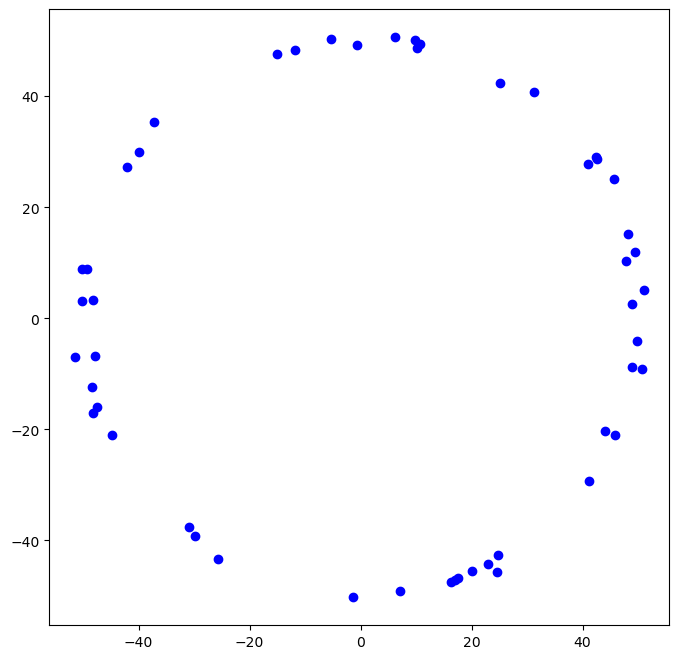

In [27]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(punti[:, 0], punti[:, 1], color='b')
ax.axis('equal')


In [28]:

baricentro = np.mean(punti, axis=0)
print(baricentro)
distanze_dal_baricentro = np.linalg.norm(punti-baricentro, axis=1)
print(np.var(distanze_dal_baricentro))

[4.30779288 0.77295305]
10.126234041641357


## Varianza delle distanze dal baricentro

Il baricentro è il punto medio della forma.

Si calcola facendo la media delle coordinate:

```python
baricentro = np.mean(punti, axis=0)
```

Poi si misura la distanza di ogni punto dal baricentro:

```python
distanze_dal_baricentro = np.linalg.norm(punti - baricentro, axis=1)
```

Se i punti stanno tutti a distanze simili dal baricentro, la varianza è bassa.

Se alcuni punti sono molto vicini e altri molto lontani, la varianza è alta.

Questa feature descrive quanto la forma è regolare rispetto al proprio centro.

Non basta da sola a riconoscere un quadrato, ma può aiutare a distinguere forme molto irregolari.

In [29]:
min_x, max_x = np.min(punti[:, 0]), np.max(punti[:,0])
min_y, max_y = np.min(punti[:, 1]), np.max(punti[:,1])
dist_sx = punti[:, 0] - min_x
dist_dx = max_x - punti[:, 0]
dist_sy = punti[:, 1] - min_y
dist_dy = max_y - punti[:, 1]
dist_x = np.minimum(dist_dx, dist_sx)
dist_xy = np.minimum(dist_x, dist_sy)
dist_bb = np.minimum(dist_xy, dist_dy)
print(np.var(dist_bb))

13.869233652008843


## Distanza dal bounding box

Il bounding box è il rettangolo minimo allineato agli assi che contiene tutti i punti della forma.

Si calcolano:

```python
min_x, max_x
min_y, max_y
```

Questi valori definiscono i quattro lati del rettangolo.

Per ogni punto, si calcola la distanza dal lato più vicino del bounding box.

Nel codice:

```python
dist_sx = punti[:, 0] - min_x
dist_dx = max_x - punti[:, 0]
dist_sy = punti[:, 1] - min_y
dist_dy = max_y - punti[:, 1]
```

Poi si prende il minimo tra queste distanze.

Per una forma simile a un quadrato, molti punti del contorno dovrebbero stare vicino ai lati del bounding box.

La varianza di queste distanze diventa una feature che descrive quanto il contorno segue il rettangolo esterno.

Calcolo centroidi e bounding box per tutti i punti:

In [30]:
varianze_dist_baricentro, varianze_dist_bb = [], []
for _, (forma, etichetta) in df.iterrows():
    punti = np.fromstring(forma, sep=',')
    punti = punti.reshape(-1,2)
    
    baricentro = np.mean(punti, axis=0)
    distanze_dal_baricentro = np.linalg.norm(punti-baricentro, axis=1)
    varianze_dist_baricentro.append(np.var(distanze_dal_baricentro))

    min_x, max_x = np.min(punti[:, 0]), np.max(punti[:,0])
    min_y, max_y = np.min(punti[:, 1]), np.max(punti[:,1])
    dist_sx = punti[:, 0] - min_x
    dist_dx = max_x - punti[:, 0]
    dist_sy = punti[:, 1] - min_y
    dist_dy = max_y - punti[:, 1]
    dist_x = np.minimum(dist_dx, dist_sx)
    dist_xy = np.minimum(dist_x, dist_sy)
    dist_bb = np.minimum(dist_xy, dist_dy)
    varianze_dist_bb.append(np.var(dist_bb))
print(varianze_dist_baricentro)
print(varianze_dist_bb)

[np.float64(47.76921569819815), np.float64(42.561111023444155), np.float64(40.24149049542978), np.float64(47.16781359216632), np.float64(58.9261645788051), np.float64(74.88167087525052), np.float64(62.14087748080169), np.float64(50.6037834263024), np.float64(80.91028979571708), np.float64(56.62469786123153), np.float64(50.251949370583134), np.float64(39.96265669751714), np.float64(116.93618547335763), np.float64(73.7956183179152), np.float64(52.37605603047961), np.float64(47.83927526290782), np.float64(56.56296596976873), np.float64(51.64706206297934), np.float64(46.67098021881532), np.float64(214.4729484276404), np.float64(144.53207718549683), np.float64(132.45901604377983), np.float64(55.26365049285098), np.float64(219.97267594860958), np.float64(54.27754906378494), np.float64(77.8097340128366), np.float64(44.827665714452635), np.float64(52.124021905068474), np.float64(79.41632409771661), np.float64(62.77697526521549), np.float64(38.71324333899572), np.float64(139.40975177058678), np

Raccolgo in un df le features estratte:

In [31]:
features_df = pd.DataFrame()
features_df['varBb'] = varianze_dist_bb
features_df['varBa'] = varianze_dist_baricentro
features_df['target'] = df[1]
features_df

,varBb,varBa,target
0,1.190578,47.769216,1
1,0.690601,42.561111,1
2,1.354718,40.241490,1
3,1.185775,47.167814,1
4,1.135357,58.926165,1
...,...,...,...
195,19.556738,46.217124,0
196,14.215843,1.153805,0
197,20.495437,52.534633,0
198,16.510940,3.490197,0


## Dataset finale delle feature

Dopo l'estrazione delle feature, ogni forma non è più rappresentata dalla sequenza completa dei punti.

Ogni forma è rappresentata da due valori:

```text
varBb = varianza delle distanze dal bounding box
varBa = varianza delle distanze dal baricentro
```

La colonna `target` contiene l'etichetta:

```text
1 = quadrato
0 = non quadrato
```

Quindi il problema torna a essere un problema standard di classificazione tabellare:

```text
input  = feature numeriche
output = classe
```

In [32]:
X = features_df.iloc[:, :-1].values
y = features_df.iloc[:, -1].values
# Dividiamo i dati usando la tua funzione train_test_split
X_train, y_train, X_test, y_test = train_test_split(X, y)

# Creiamo l'istanza del tuo KNN
knn_model = KNN()

# "Allenamento": il modello costruisce il KDTree
knn_model.fit(X_train, y_train)

print("Sistema pronto e allenato!")

Sistema pronto e allenato!


In [33]:
preds = np.array([knn_model.predict(x)[0] for x in X_test]) == y_test
print(preds)
accuracy=preds.sum()/preds.shape[0]
print(f'accuracy: {accuracy}')


[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True]
accuracy: 1.0


## Interpretazione dell'accuracy

L'accuracy misura la frazione di forme classificate correttamente.

La formula è:

$$
Accuracy =
\frac{\text{predizioni corrette}}
{\text{numero totale di esempi del test set}}
$$

In questo esercizio, il k-NN non lavora direttamente sui punti del contorno.

Lavora sulle feature geometriche estratte.

Quindi la qualità del classificatore dipende molto dalla qualità delle feature scelte.

Se le feature separano bene quadrati e non quadrati, anche un classificatore semplice come k-NN può ottenere buoni risultati.